# Pipeline vs Single-Node Comparison - Mamba-130M

Compares distributed two-node pipeline inference against the single-node baseline.
Network transfer cost is contextualized using raw ping benchmarks from
`scripts/benchmark_network.py`.

## Data Sources

The CSVs are generated by running:

```bash
python scripts/profile_single_node.py
python scripts/profile_pipeline.py
python scripts/benchmark_network.py --worker <host>:<port>
```

In [1]:
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 12

## Load Data

In [4]:
sn = pd.read_csv("../benchmarks/single_node_baseline_pi.csv")
pp = pd.read_csv("../benchmarks/pipeline_baseline_pi.csv")
pp


,timestamp,hostname,arch,model_name,tokens,pass_type,mean_ms,median_ms,min_ms,max_ms,p95_ms,peak_memory_mb,num_nodes,node_latencies_ms,communication_overhead_ms
0,2026-07-14 10:24:49,rpi-master,mamba,mamba-130m,64,forward_pass,1028.60,1027.80,1008.64,1056.02,1056.02,1387,2,"[334.4, 435.4]",258.80
1,2026-07-14 10:24:49,rpi-master,mamba,mamba-130m,64,generate_30,35900.32,35772.85,35118.39,37820.79,37820.79,1514,2,"[376.96, 488.44]",9938.36
2,2026-07-14 10:24:49,rpi-master,mamba,mamba-130m,128,forward_pass,1755.92,1756.41,1723.47,1791.65,1791.65,1485,2,"[560.37, 689.95]",505.59
3,2026-07-14 10:24:49,rpi-master,mamba,mamba-130m,128,generate_30,58600.56,58803.77,57375.06,60030.11,60030.11,1509,2,"[612.53, 758.17]",17479.45
4,2026-07-14 10:24:49,rpi-master,mamba,mamba-130m,512,forward_pass,6700.04,6689.57,6570.28,6924.45,6924.45,1411,2,"[2190.46, 2564.54]",1945.05
5,2026-07-14 10:24:49,rpi-master,mamba,mamba-130m,512,generate_30,199680.51,199353.85,198228.38,202666.11,202666.11,1416,2,"[2151.93, 2572.93]",57934.59
6,2026-07-14 10:24:49,rpi-master,mamba,mamba-130m,1024,forward_pass,13811.17,13693.01,13577.73,14899.72,14899.72,1073,2,"[4655.89, 5611.8]",3543.48
7,2026-07-14 10:24:49,rpi-master,mamba,mamba-130m,1024,generate_30,403187.07,402860.62,397863.29,409556.07,409556.07,1079,2,"[4320.56, 5203.15]",117475.57


## Latency vs. Sequence Length

Single-node vs. pipeline latency for each pass type. The pipeline adds a
network round-trip per forward call - this chart shows whether that overhead
is significant relative to compute time at each sequence length.

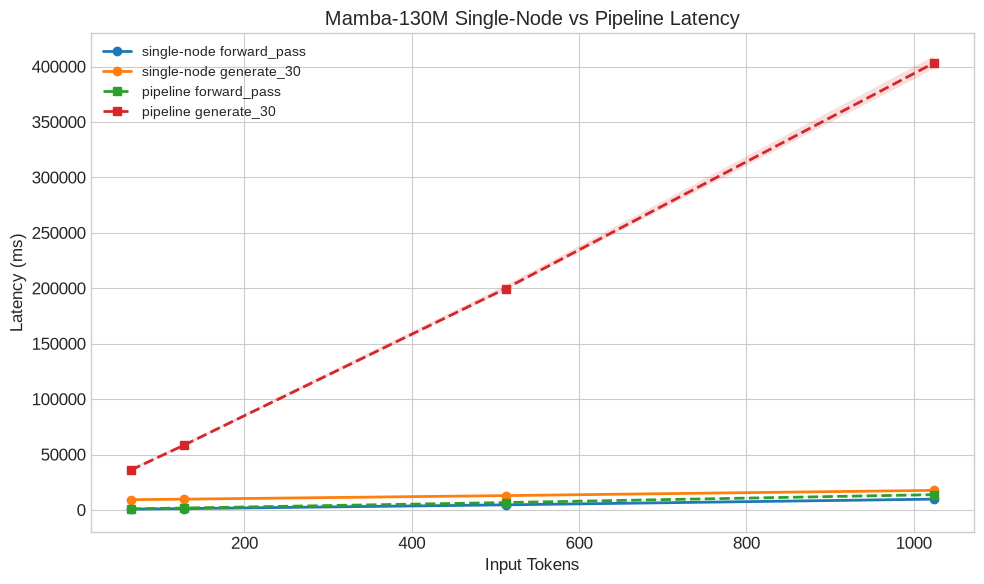

In [5]:
fig, ax = plt.subplots()

for pass_type, group in sn.groupby("pass_type"):
    group = group.sort_values("tokens")
    ax.plot(group["tokens"], group["mean_ms"], marker="o", linewidth=2, label=f"single-node {pass_type}")
    ax.fill_between(group["tokens"], group["min_ms"], group["max_ms"], alpha=0.15)

for pass_type, group in pp.groupby("pass_type"):
    group = group.sort_values("tokens")
    ax.plot(group["tokens"], group["mean_ms"], marker="s", linewidth=2, linestyle="--", label=f"pipeline {pass_type}")
    ax.fill_between(group["tokens"], group["min_ms"], group["max_ms"], alpha=0.15)

ax.set_xlabel("Input Tokens")
ax.set_ylabel("Latency (ms)")
ax.set_title("Mamba-130M Single-Node vs Pipeline Latency")
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

## Per-Node Latency Breakdown

Stacked bars decompose total pipeline latency into per-node compute time and
inter-node communication overhead. A large comm overhead segment indicates the
network is the bottleneck rather than compute.

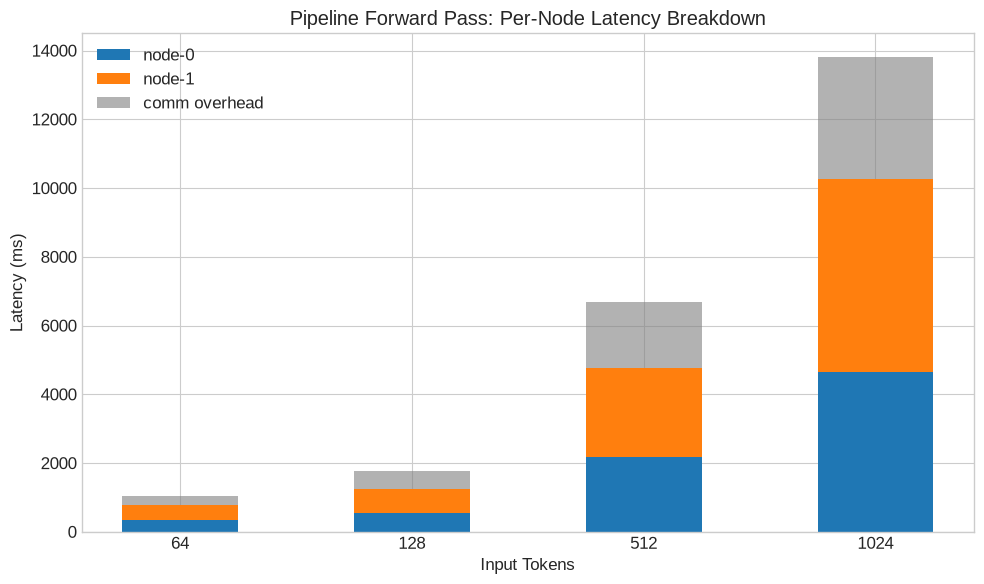

In [6]:
fp = pp[pp["pass_type"] == "forward_pass"].sort_values("tokens").copy()
fp["node_lats"] = fp["node_latencies_ms"].apply(json.loads)
num_nodes = fp["num_nodes"].iloc[0]

x = np.arange(len(fp))
width = 0.5

fig, ax = plt.subplots()

bottom = np.zeros(len(fp))
for node_idx in range(num_nodes):
    values = np.array([row[node_idx] if node_idx < len(row) else 0 for row in fp["node_lats"]])
    ax.bar(x, values, width, bottom=bottom, label=f"node-{node_idx}")
    bottom += values

ax.bar(x, fp["communication_overhead_ms"].values, width, bottom=bottom, label="comm overhead", color="gray", alpha=0.6)

ax.set_xticks(x)
ax.set_xticklabels(fp["tokens"].astype(str))
ax.set_xlabel("Input Tokens")
ax.set_ylabel("Latency (ms)")
ax.set_title("Pipeline Forward Pass: Per-Node Latency Breakdown")
ax.legend()
plt.tight_layout()
plt.show()

## Communication Overhead vs Network Baseline

Left: raw Ping RTT across payload sizes - establishes the minimum achievable
transfer cost at the network level. Right: pipeline comm overhead plotted
against the 0-byte RTT floor, separating activation transfer cost from
gRPC framing and scheduling jitter.

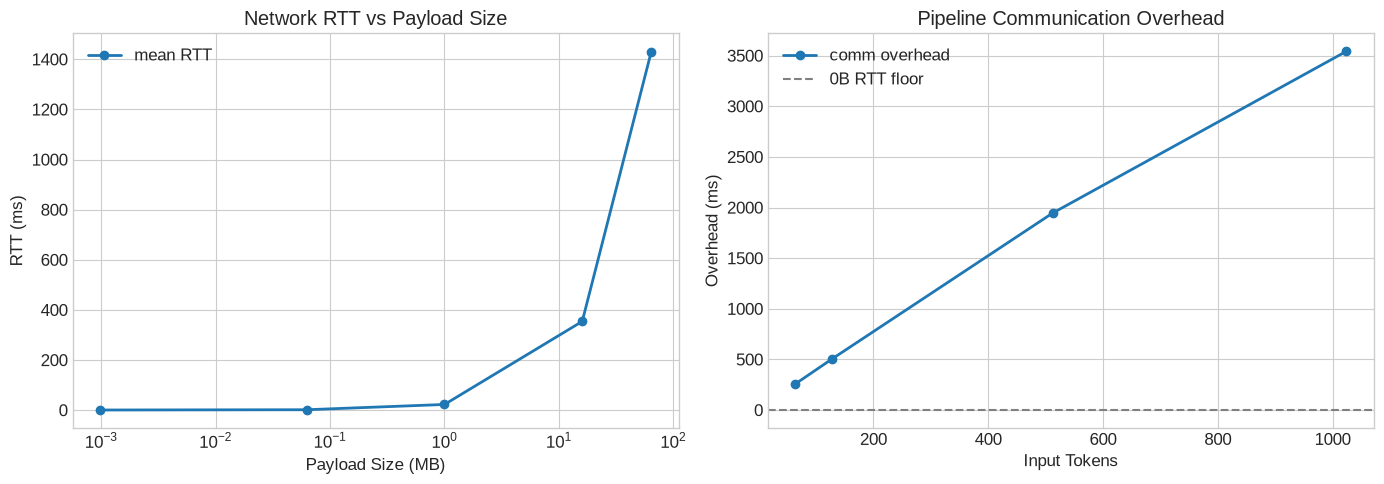

In [8]:
net = pd.read_csv("../benchmarks/network_baseline_pi.csv")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
net_f = net[net["payload_bytes"] > 0].sort_values("payload_bytes")
ax.semilogx(net_f["payload_bytes"] / (1024 * 1024), net_f["mean_ms"], marker="o", linewidth=2, label="mean RTT")
ax.fill_between(net_f["payload_bytes"] / (1024 * 1024), net_f["min_ms"], net_f["max_ms"], alpha=0.15)
ax.set_xlabel("Payload Size (MB)")
ax.set_ylabel("RTT (ms)")
ax.set_title("Network RTT vs Payload Size")
ax.legend()

ax = axes[1]
fp_comm = pp[pp["pass_type"] == "forward_pass"].sort_values("tokens")
ax.plot(fp_comm["tokens"], fp_comm["communication_overhead_ms"], marker="o", linewidth=2, label="comm overhead")
ax.axhline(y=net[net["payload_bytes"] == 0]["mean_ms"].mean(), linestyle="--", color="gray", label="0B RTT floor")
ax.set_xlabel("Input Tokens")
ax.set_ylabel("Overhead (ms)")
ax.set_title("Pipeline Communication Overhead")
ax.legend()

plt.tight_layout()
plt.show()

## Summary Table

In [9]:
sn_s = sn[["hostname", "tokens", "pass_type", "mean_ms", "median_ms", "p95_ms", "peak_memory_mb"]].copy()
sn_s["mode"] = "single-node"

pp_s = pp[["hostname", "tokens", "pass_type", "mean_ms", "median_ms", "p95_ms", "peak_memory_mb", "num_nodes"]].copy()
pp_s["mode"] = pp_s["num_nodes"].apply(lambda n: f"pipeline-{n}")

summary = pd.concat([
    sn_s[["mode", "hostname", "tokens", "pass_type", "mean_ms", "median_ms", "p95_ms", "peak_memory_mb"]],
    pp_s[["mode", "hostname", "tokens", "pass_type", "mean_ms", "median_ms", "p95_ms", "peak_memory_mb"]],
], ignore_index=True).sort_values(["pass_type", "tokens", "mode"])

summary.columns = ["Mode", "Host", "Tokens", "Pass Type", "Mean (ms)", "Median (ms)", "P95 (ms)", "Peak Mem (MB)"]
summary

,Mode,Host,Tokens,Pass Type,Mean (ms),Median (ms),P95 (ms),Peak Mem (MB)
8,pipeline-2,rpi-master,64,forward_pass,1028.60,1027.80,1056.02,1387
0,single-node,rpi-master,64,forward_pass,743.87,743.49,748.56,1066
10,pipeline-2,rpi-master,128,forward_pass,1755.92,1756.41,1791.65,1485
2,single-node,rpi-master,128,forward_pass,1196.72,1196.71,1200.76,1082
12,pipeline-2,rpi-master,512,forward_pass,6700.04,6689.57,6924.45,1411
4,single-node,rpi-master,512,forward_pass,4606.50,4605.63,4633.48,1362
14,pipeline-2,rpi-master,1024,forward_pass,13811.17,13693.01,14899.72,1073
6,single-node,rpi-master,1024,forward_pass,9761.46,9766.15,9789.34,1436
9,pipeline-2,rpi-master,64,generate_30,35900.32,35772.85,37820.79,1514
1,single-node,rpi-master,64,generate_30,9299.78,9307.23,9325.75,1066
